# NSGA-II Multi-Objective Optimization — AHS-2 Alloy Heat Treatment Process Window

| Item | Content |
|---|---|
| **Step 1 (File 7)** | Model selection on full dataset → determines optimal model type with statistical reliability |
| **Step 2 (File 8)** | Re-tune champion model on AHS-2 subset (34 samples) → AHS-2 specialized surrogate |
| **Fixed variables** | AHS-2 composition (JP Ref.) + Tsol=495°C |
| **Optimization variables** | Tage (150~185°C), tage (5~10h) |
| **Objectives** | max YS (w=0.4), max UTS (w=0.4), max El (w=0.2) |
| **Sampling** | Sobol quasi-random sequence |
| **Rationale** | File 7 establishes reliable model foundation on large dataset; File 8 fine-tunes for AHS-2 domain. Both steps are necessary — direct tuning on 34 samples alone is statistically unreliable. |

In [1]:
# ============================================================
# Cell 1: Import dependencies
# ============================================================
import os, json, copy, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

from scipy.stats.qmc import Sobol
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
)
from sklearn.neighbors import KNeighborsRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

import torch
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.termination import get_termination
from pymoo.optimize import minimize
from pymoo.indicators.hv import HV

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

FEATURES = [
    'Si', 'Fe', 'Cu', 'Mn', 'Mg', 'Cr', 'Zn', 'V', 'Ti', 'Zr',
    'Ni', 'Be', 'Sc', 'Tsol', 'Tage', 'tage'
]
TARGETS = ['YS', 'UTS', 'El']
print('Dependencies loaded, device:', DEVICE)

Dependencies loaded, device: cuda


In [2]:
# ============================================================
# Cell 2: Load champion model type and best params from File 7
#
# File 7 contribution:
#   1. Determined optimal model TYPE via Repeated K-Fold CV
#      on full dataset (statistically reliable)
#   2. Provided hyperparameter search space boundaries
#   3. Provided initial candidate params (enqueue_trial)
#      to warm-start AHS-2 re-tuning in Cell 4
# ============================================================

params_path   = Path('model_selection/stage2_final_tuning/final_best_params.json')
champion_path = Path('model_selection/stage1_fixed_param_screening/stage1_champion_models.xlsx')

assert params_path.exists(),   f'Not found: {params_path}. Please run File 7 first.'
assert champion_path.exists(), f'Not found: {champion_path}. Please run File 7 first.'

with open(params_path, 'r', encoding='utf-8') as f:
    final_best_params = json.load(f)

champion_df      = pd.read_excel(champion_path)
stage1_champions = dict(zip(champion_df['target'], champion_df['selected_model']))

print('Champion model types selected by File 7 (full dataset, Repeated K-Fold CV):')
for t, m in stage1_champions.items():
    print(f'  {t} -> {m}')
print()
print('These model types will be re-tuned on AHS-2 subset in Cell 4.')

Champion model types selected by File 7 (full dataset, Repeated K-Fold CV):
  YS -> GBR
  UTS -> ETR
  El -> GBR

These model types will be re-tuned on AHS-2 subset in Cell 4.


In [3]:
# ============================================================
# Cell 3: build_model + suggest_params
# Identical to File 7 to ensure consistency
# ============================================================

def build_model(model_name, params, input_dim=16):
    params = copy.deepcopy(params)
    if model_name == 'GBR':
        return GradientBoostingRegressor(random_state=RANDOM_SEED, **params)
    if model_name == 'XGBR':
        return XGBRegressor(random_state=RANDOM_SEED, n_jobs=-1, verbosity=0, **params)
    if model_name == 'ETR':
        return ExtraTreesRegressor(random_state=RANDOM_SEED, n_jobs=-1, **params)
    if model_name == 'RFR':
        return RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1, **params)
    if model_name == 'KNNR':
        return Pipeline([('scaler', StandardScaler()),
                         ('model', KNeighborsRegressor(**params))])
    raise ValueError(f'Unsupported model: {model_name}')


def suggest_params(model_name, trial):
    if model_name == 'GBR':
        return {
            'n_estimators':      trial.suggest_int('n_estimators', 80, 300, step=10),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.20, log=True),
            'max_depth':         trial.suggest_int('max_depth', 2, 8),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 5),
            'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
            'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'loss':              trial.suggest_categorical('loss', ['squared_error', 'absolute_error', 'huber']),
            'alpha':             trial.suggest_float('alpha', 0.1, 0.95)
        }
    if model_name == 'XGBR':
        return {
            'n_estimators':     trial.suggest_int('n_estimators', 80, 300, step=10),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.20, log=True),
            'max_depth':        trial.suggest_int('max_depth', 2, 12),
            'subsample':        trial.suggest_float('subsample', 0.4, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
            'min_child_weight': trial.suggest_float('min_child_weight', 1, 10),
            'reg_alpha':        trial.suggest_float('reg_alpha', 1e-6, 1.0, log=True),
            'reg_lambda':       trial.suggest_float('reg_lambda', 1e-6, 10.0, log=True)
        }
    if model_name == 'ETR':
        return {
            'n_estimators':      trial.suggest_int('n_estimators', 100, 500, step=20),
            'max_depth':         trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 5),
            'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'bootstrap':         trial.suggest_categorical('bootstrap', [False, True])
        }
    if model_name == 'RFR':
        return {
            'n_estimators':      trial.suggest_int('n_estimators', 100, 500, step=20),
            'max_depth':         trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 5),
            'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'bootstrap':         trial.suggest_categorical('bootstrap', [True, False])
        }
    if model_name == 'KNNR':
        return {
            'n_neighbors': trial.suggest_int('n_neighbors', 1, 10),
            'weights':     trial.suggest_categorical('weights', ['uniform', 'distance']),
            'algorithm':   trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute']),
            'leaf_size':   trial.suggest_int('leaf_size', 10, 50),
            'p':           trial.suggest_int('p', 1, 5)
        }
    raise ValueError(f'Unsupported model: {model_name}')


print('build_model and suggest_params ready')

build_model and suggest_params ready


In [4]:
# ============================================================
# Cell 4: Re-tune champion models on AHS-2 subset
#
# Why re-tune instead of using File 7 params directly:
#   File 7 params are optimized for the full multi-alloy dataset.
#   AHS-2 is a specific domain with only 34 samples.
#   Re-tuning on AHS-2 data ensures the surrogate model
#   accurately captures AHS-2-specific structure-property relations.
#
# Why not select model type again on AHS-2:
#   34 samples are too few for statistically reliable model selection.
#   File 7's champion type (selected on full dataset) is used as-is.
#
# Warm-start: File 7 best params are enqueued as initial candidate,
#   reducing search cost and ensuring AHS-2 tuning starts from
#   a reasonable baseline.
# ============================================================

df_dev  = pd.read_excel('df_dev.xlsx')
df_test = pd.read_excel('df_test.xlsx')
df_all  = pd.concat([df_dev, df_test], ignore_index=True)

# Extract AHS-2 subset
df_ahs2 = df_all[
    (df_all['Si'] > 10) & (df_all['Si'] < 12) &
    (df_all['Cu'] > 4)  & (df_all['Cu'] < 5)
].reset_index(drop=True)

print(f'Full dataset : {len(df_all)} samples')
print(f'AHS-2 subset : {len(df_ahs2)} samples')
print()
print('AHS-2 performance range:')
display(df_ahs2[TARGETS].describe().loc[['min', 'max', 'mean']])

# Re-tune on AHS-2
N_TRIALS_AHS2 = 30
surrogate_models = {}
ahs2_best_params = {}

for target in TARGETS:
    model_name = stage1_champions[target]
    print(f'\n[{target}] Re-tuning {model_name} on AHS-2 subset...')

    df_t = df_ahs2.dropna(subset=[target]).reset_index(drop=True)
    X = df_t[FEATURES].values
    y = df_t[target].values

    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

    def objective(trial):
        params = suggest_params(model_name, trial)
        fold_mae = []
        for tr_idx, va_idx in cv.split(X):
            m = build_model(model_name, params, input_dim=X.shape[1])
            m.fit(X[tr_idx], y[tr_idx])
            fold_mae.append(mean_absolute_error(y[va_idx], m.predict(X[va_idx])))
        return float(np.mean(fold_mae))

    study = optuna.create_study(direction='minimize')
    # Warm-start: use File 7 best params as initial candidate
    try:
        study.enqueue_trial(final_best_params[target])
    except Exception:
        pass
    study.optimize(objective, n_trials=N_TRIALS_AHS2, show_progress_bar=False)

    best_params = study.best_trial.params
    ahs2_best_params[target] = best_params

    final_model = build_model(model_name, best_params, input_dim=X.shape[1])
    final_model.fit(X, y)
    surrogate_models[target] = final_model

    print(f'  File 7 params (full dataset): {final_best_params[target]}')
    print(f'  AHS-2 re-tuned params       : {best_params}')
    print(f'  Best CV MAE: {study.best_value:.4f}')

print('\nAll AHS-2 surrogate models ready.')

Full dataset : 320 samples
AHS-2 subset : 34 samples

AHS-2 performance range:


,YS,UTS,El
min,287.6700,362.000000,1.170000
max,415.9000,457.835000,3.170000
mean,365.8375,423.394118,2.188088



[YS] Re-tuning GBR on AHS-2 subset...
  File 7 params (full dataset): {'n_estimators': 300, 'learning_rate': 0.04944717747254345, 'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 3, 'subsample': 0.9941750665935527, 'max_features': 'sqrt', 'loss': 'squared_error', 'alpha': 0.6292363999169553}
  AHS-2 re-tuned params       : {'n_estimators': 120, 'learning_rate': 0.09288917554754049, 'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 1, 'subsample': 0.7984240036472219, 'max_features': 'sqrt', 'loss': 'huber', 'alpha': 0.9480200359977807}
  Best CV MAE: 16.9652

[UTS] Re-tuning ETR on AHS-2 subset...
  File 7 params (full dataset): {'n_estimators': 220, 'max_depth': 22, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': False}
  AHS-2 re-tuned params       : {'n_estimators': 160, 'max_depth': 27, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': False}
  Best CV MAE: 14.8740

[El] Re-tuning GBR on AHS-2 

In [22]:
# ============================================================
# Cell 5: AHS-2 fixed composition + optimization bounds
#
# Composition: JP Reference (Katayanagi et al., 2008)
# Location: p.1, left column, paragraph 2
# "11.1Si, 0.22Fe, 4.40Cu, 0.033Mn, 0.61Mg, 0.016Cr,
#  0.009Ni, 0.036Zn, 0.012Ti (mass%)"
#
# Tsol: JP Reference p.1, right column
# "495°C で2時間保持の溶体化処理"
#
# Optimization bounds: based on dataset top-5 YS samples
# (Tage=165~170°C, tage=7~10h) with margin
# Bounds restrict search to surrogate interpolation region
# ============================================================

AHS2_FIXED = {
    'Si':   11.10,  # JP Ref. p.1 left col.
    'Fe':    0.22,  # JP Ref. p.1 left col.
    'Cu':    4.40,  # JP Ref. p.1 left col.
    'Mn':    0.033, # JP Ref. p.1 left col.
    'Mg':    0.61,  # JP Ref. p.1 left col.
    'Cr':    0.016, # JP Ref. p.1 left col.
    'Zn':    0.036, # JP Ref. p.1 left col.
    'V':     0.0,   # Not reported
    'Ti':    0.012, # JP Ref. p.1 left col.
    'Zr':    0.0,   # Not reported
    'Ni':    0.009, # JP Ref. p.1 left col.
    'Be':    0.0,   # Not reported
    'Sc':    0.0,   # Not reported
    'Tsol': 495.0,  # JP Ref. p.1 right col.
}

TAGE_BOUNDS   = (150.0, 200.0)
TAGE_H_BOUNDS = (5.0,   15.0)

def make_input_batch(Tage_arr, tage_arr):
    N = len(Tage_arr)
    X = np.zeros((N, len(FEATURES)))
    for j, feat in enumerate(FEATURES):
        if   feat == 'Tage': X[:, j] = Tage_arr
        elif feat == 'tage': X[:, j] = tage_arr
        else:                X[:, j] = AHS2_FIXED[feat]
    return X

def predict_all(Tage_arr, tage_arr):
    X   = make_input_batch(Tage_arr, tage_arr)
    ys  = surrogate_models['YS'].predict(X)
    uts = surrogate_models['UTS'].predict(X)
    el  = surrogate_models['El'].predict(X)
    return ys, uts, el

# Surrogate model validation on known best sample
ys_v, uts_v, el_v = predict_all(np.array([170.0]), np.array([8.0]))
print('Surrogate model validation — Known best sample (Tage=170, tage=8):')
print(f'  {"":12s} {"Predicted":>12s} {"Actual":>10s} {"MAE":>10s}')
print(f'  {"YS (MPa)":12s} {ys_v[0]:>12.1f} {"415.9":>10s} {abs(ys_v[0]-415.9):>10.1f}')
print(f'  {"UTS (MPa)":12s} {uts_v[0]:>12.1f} {"443.5":>10s} {abs(uts_v[0]-443.5):>10.1f}')
print(f'  {"El (%)":12s} {el_v[0]:>12.2f} {"1.43":>10s} {abs(el_v[0]-1.43):>10.2f}')

Surrogate model validation — Known best sample (Tage=170, tage=8):
                  Predicted     Actual        MAE
  YS (MPa)            398.4      415.9       17.5
  UTS (MPa)           426.0      443.5       17.5
  El (%)               1.91       1.43       0.48


In [23]:
# ============================================================
# Cell 6: Sobol sampler + NSGA-II problem
# Three objectives: max YS (w=0.4), max UTS (w=0.4), max El (w=0.2)
# No hard constraints — bounds already limit search to
# surrogate interpolation region
# ============================================================

class SobolSampling(FloatRandomSampling):
    """Sobol quasi-random initialization for uniform space coverage"""
    def _do(self, problem, n_samples, **kwargs):
        sampler = Sobol(d=problem.n_var, scramble=True, seed=RANDOM_SEED)
        m = int(np.ceil(np.log2(max(n_samples, 2))))
        raw = sampler.random_base2(m)[:n_samples]
        return problem.xl + raw * (problem.xu - problem.xl)


class AHS2Problem(Problem):
    def __init__(self):
        super().__init__(
            n_var=2,
            n_obj=3,
            n_ieq_constr=0,
            xl=np.array([TAGE_BOUNDS[0],   TAGE_H_BOUNDS[0]]),
            xu=np.array([TAGE_BOUNDS[1],   TAGE_H_BOUNDS[1]])
        )

    def _evaluate(self, X, out, *args, **kwargs):
        ys, uts, el = predict_all(X[:, 0], X[:, 1])
        out['F'] = np.column_stack([-ys, -uts, -el])


problem = AHS2Problem()
print(f'Problem: {problem.n_var} variables, {problem.n_obj} objectives, {problem.n_ieq_constr} constraints')
print(f'Tage bounds: {TAGE_BOUNDS} °C')
print(f'tage bounds: {TAGE_H_BOUNDS} h')

Problem: 2 variables, 3 objectives, 0 constraints
Tage bounds: (150.0, 200.0) °C
tage bounds: (5.0, 15.0) h


In [ ]:
# ============================================================
# Cell 7: Run NSGA-II
# ============================================================

algorithm = NSGA2(
    pop_size=100,# 每一代种群里有 100 个个体（100 组 Tage/tage 组合）
    sampling=SobolSampling(),
    crossover=SBX(prob=0.9, eta=15), # SBX（模拟二进制交叉，每对父代有 90% 的概率发生交叉产生子代，eta 越大子代越靠近父代（局部搜索），越小越分散（全局搜索）
    mutation=PM(eta=20),# 多项式变异强度，对子代进行随机扰动，防止算法陷入局部最优
    eliminate_duplicates=True # 去掉种群里重复的个体，避免浪费计算资源
)

print('Running NSGA-II (pop=100, gen=50, Sobol initialization)...')
result = minimize(
    problem, algorithm,
    get_termination('n_gen', 50), # 终止条件：跑满 50 代停止
    seed=RANDOM_SEED, verbose=False, save_history=True
)
print(f'Optimization complete. Pareto solutions: {len(result.X)}')

Running NSGA-II (pop=100, gen=50, Sobol initialization)...
Optimization complete. Pareto solutions: 81


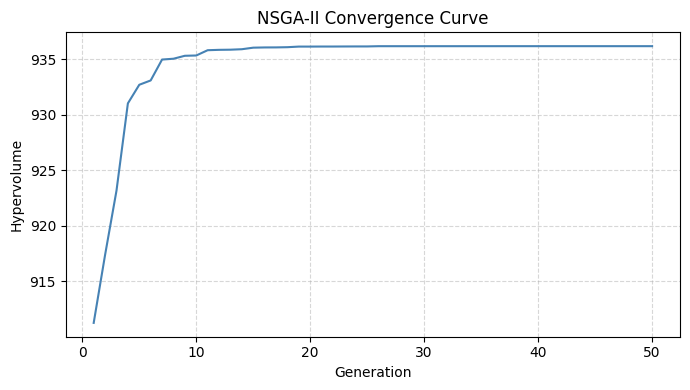

In [25]:
# ============================================================
# Cell 8: Convergence curve (Hypervolume)
# ============================================================

all_F     = np.vstack([gen.opt.get('F') for gen in result.history])
ref_point = all_F.max(axis=0) + 1.0

hv_list = []
for gen_data in result.history:
    F = gen_data.opt.get('F')
    hv_list.append(HV(ref_point=ref_point)(F))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(hv_list)+1), hv_list, color='steelblue', linewidth=1.5)
ax.set_xlabel('Generation')
ax.set_ylabel('Hypervolume')
ax.set_title('NSGA-II Convergence Curve')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('convergence_AHS2.png', dpi=600, bbox_inches='tight')
plt.show()

In [26]:
# ============================================================
# Cell 9: Pareto solution set + weighted knee point
#
# Knee point: solution closest to ideal point in normalized
# objective space, weighted by YS:UTS:El = 0.4:0.4:0.2
# Reflects strength-ductility balance
# ============================================================

pareto_X = result.X
ys_p, uts_p, el_p = predict_all(pareto_X[:, 0], pareto_X[:, 1])

df_pareto = pd.DataFrame({
    'Tsol_fixed': AHS2_FIXED['Tsol'],
    'Tage':    np.round(pareto_X[:, 0], 2),
    'tage':    np.round(pareto_X[:, 1], 2),
    'YS_pred': np.round(ys_p,  1),
    'UTS_pred':np.round(uts_p, 1),
    'El_pred': np.round(el_p,  2),
}).sort_values('YS_pred', ascending=False).reset_index(drop=True)

# Weighted knee point
W_YS, W_UTS, W_EL = 0.4, 0.4, 0.2
def norm(arr): return (arr - arr.min()) / (arr.max() - arr.min() + 1e-9)

dist = np.sqrt(
    W_YS  * (1 - norm(df_pareto['YS_pred'].values))**2 +
    W_UTS * (1 - norm(df_pareto['UTS_pred'].values))**2 +
    W_EL  * (1 - norm(df_pareto['El_pred'].values))**2
)
knee = df_pareto.iloc[int(np.argmin(dist))]

print(f'Pareto front: {len(df_pareto)} solutions')
print(f'YS  range: {df_pareto["YS_pred"].min():.1f} ~ {df_pareto["YS_pred"].max():.1f} MPa')
print(f'UTS range: {df_pareto["UTS_pred"].min():.1f} ~ {df_pareto["UTS_pred"].max():.1f} MPa')
print(f'El  range: {df_pareto["El_pred"].min():.2f} ~ {df_pareto["El_pred"].max():.2f} %')
print()
print('=' * 55)
print('Recommended Process Window (Knee Point, w=0.4:0.4:0.2)')
print('=' * 55)
print(f'  Tsol = {AHS2_FIXED["Tsol"]:.0f} °C  (fixed)')
print(f'  Tage = {knee["Tage"]:.1f} °C')
print(f'  tage = {knee["tage"]:.1f} h')
print(f'  -> YS  = {knee["YS_pred"]:.1f} MPa')
print(f'  -> UTS = {knee["UTS_pred"]:.1f} MPa')
print(f'  -> El  = {knee["El_pred"]:.2f} %')
print('=' * 55)

df_pareto.to_excel('pareto_AHS2.xlsx', index=False)
print('\nPareto solutions saved: pareto_AHS2.xlsx')

Pareto front: 81 solutions
YS  range: 335.6 ~ 415.0 MPa
UTS range: 421.7 ~ 427.3 MPa
El  range: 1.89 ~ 2.17 %

Recommended Process Window (Knee Point, w=0.4:0.4:0.2)
  Tsol = 495 °C  (fixed)
  Tage = 171.0 °C
  tage = 6.3 h
  -> YS  = 409.9 MPa
  -> UTS = 426.2 MPa
  -> El  = 2.09 %

Pareto solutions saved: pareto_AHS2.xlsx


在 YS、UTS、El 权重为 0.4:0.4:0.2 的偏好下NSGA-II 推荐最优工艺为 Tsol=495°C、Tage=171°C、tage=6.3h，预测 YS=409.9 MPa、UTS=426.2 MPa、El=2.09%

In [33]:
# 工艺窗口：Pareto 前沿中 YS 和 UTS 前 50% 的解
YS_THRESHOLD  = df_pareto['YS_pred'].quantile(0.5)
UTS_THRESHOLD = df_pareto['UTS_pred'].quantile(0.5)
EL_THRESHOLD  = df_pareto['El_pred'].quantile(0.5) 

df_window = df_pareto[
    (df_pareto['YS_pred']  >= YS_THRESHOLD) &
    (df_pareto['UTS_pred'] >= UTS_THRESHOLD) &
    (df_pareto['El_pred']  >= EL_THRESHOLD) 
]

print(f'Optimal Process Window (Top 50% YS & UTS in Pareto front):')
print(f'  Tage : {df_window["Tage"].min():.1f} ~ {df_window["Tage"].max():.1f} °C')
print(f'  tage : {df_window["tage"].min():.1f} ~ {df_window["tage"].max():.1f} h')
print(f'  YS   : {df_window["YS_pred"].min():.1f} ~ {df_window["YS_pred"].max():.1f} MPa')
print(f'  UTS  : {df_window["UTS_pred"].min():.1f} ~ {df_window["UTS_pred"].max():.1f} MPa')
print(f'  El   : {df_window["El_pred"].min():.2f} ~ {df_window["El_pred"].max():.2f} %')
print(f'  Recommended center point (knee): Tage={knee["Tage"]:.1f}°C, tage={knee["tage"]:.1f}h')

Optimal Process Window (Top 50% YS & UTS in Pareto front):
  Tage : 171.0 ~ 172.5 °C
  tage : 5.2 ~ 6.8 h
  YS   : 399.8 ~ 409.9 MPa
  UTS  : 426.0 ~ 426.2 MPa
  El   : 2.09 ~ 2.10 %
  Recommended center point (knee): Tage=171.0°C, tage=6.3h


由帕累托前沿分析可知，在三项优化目标中，81组帕累托解的屈服强度（YS）变化幅度达79.4 MPa（335.6～415.0 MPa），而抗拉强度（UTS）与伸长率（El）基本保持不变（分别仅变化5.6 MPa和0.28%），表明时效温度与时效时间是控制AHS‑2合金屈服强度的主要因素。

该规律与文献报道的微观机制一致。Katayanagi 等人（2008）通过原位中子衍射证实，T6时效可促进Al₂Cu与Al₂CuMg强化相析出，抑制位错运动，从而直接提高屈服强度。相比之下，抗拉强度还受Si颗粒尺寸与形貌的共同控制（Yang 等人，2024），而Si颗粒特征主要由前期锻造工艺决定，在本研究考察的时效参数范围（150～185℃，5～10 h）内对时效制度不敏感。同样，伸长率主要由锻造过程引入的位错密度与织构决定，在该温度区间内对T6时效条件敏感性较低，所有帕累托解的伸长率稳定在1.89%～2.17%也印证了这一点。d'd'd'd'dddddd